Original Dataset:
   AnnualIncome  SpendingScore
0          15.0             39
1          15.5             42
2          16.0             45
3          16.5             48
4          17.0             51

Scaled Dataset:
   AnnualIncome  SpendingScore
0     -0.869761      -0.135877
1     -0.838899      -0.033387
2     -0.808036       0.069103
3     -0.777174       0.171594
4     -0.746311       0.274084

Dataset with Cluster Assignments:
   AnnualIncome  SpendingScore  Cluster
0          15.0             39        2
1          15.5             42        2
2          16.0             45        2
3          16.5             48        2
4          17.0             51        2


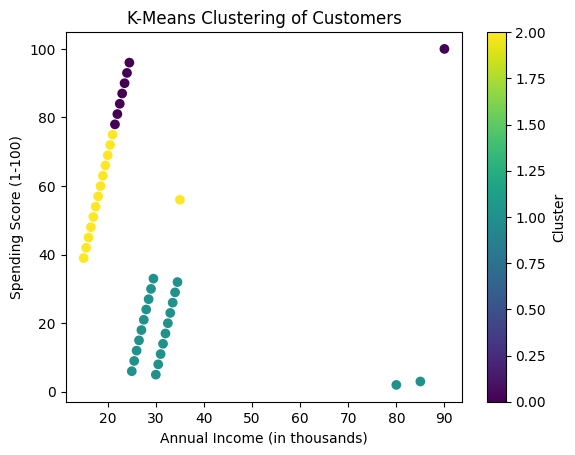

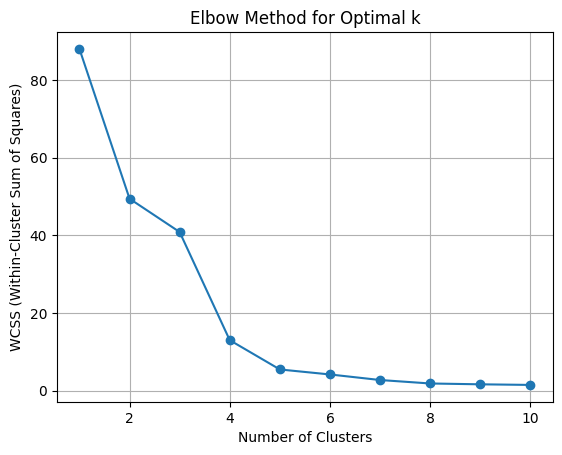

In [1]:
"""
K-Means Clustering for Customer Segmentation

This script demonstrates k-means clustering on a customer dataset containing
annual income and spending scores. It includes data normalization, cluster
assignment, visualization, and the elbow method for determining optimal clusters.

Dependencies:
    - pandas: Data manipulation and analysis
    - matplotlib: Data visualization
    - scikit-learn: Machine learning algorithms and preprocessing

Author: GitHub Copilot
Date: January 2026
"""

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans  # type: ignore[import-untyped]
from sklearn.preprocessing import StandardScaler  # type: ignore[import-untyped]

# Create a sample dataset with customer annual income and spending score
# This dataset contains two features:
# AnnualIncome: Annual income of the customer in thousands.
# SpendingScore: A score assigned based on customer behavior, from 1 (low) to 100 (high).
data = {'AnnualIncome': [
        15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5, 
        20, 20.5, 21, 21.5, 22, 22.5, 23, 23.5, 24, 24.5, 
        25, 25.5, 26, 26.5, 27, 27.5, 28, 28.5, 29, 29.5, 
        30, 30.5, 31, 31.5, 32, 32.5, 33, 33.5, 34, 34.5, 
        35,   # Normal points
        80, 85, 90  # Outliers
    ],
    'SpendingScore': [
        39, 42, 45, 48, 51, 54, 57, 60, 63, 66,
        69, 72, 75, 78, 81, 84, 87, 90, 93, 96,
        6, 9, 12, 15, 18, 21, 24, 27, 30, 33,
        5, 8, 11, 14, 17, 20, 23, 26, 29, 32,
        56,   # Normal points
        2, 3, 100  # Outliers
    ]}

# Convert dictionary to DataFrame for easier manipulation
df = pd.DataFrame(data)

# Display the first few rows of the dataset
print("Original Dataset:")
print(df.head())

# Normalize the dataset using StandardScaler
# Normalization ensures all features contribute equally to distance calculations
# by scaling them to have mean=0 and standard deviation=1
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Convert the scaled data back into a DataFrame for easier handling
df_scaled = pd.DataFrame(df_scaled, columns=['AnnualIncome', 'SpendingScore'])
print("\nScaled Dataset:")
print(df_scaled.head())

# Initialize the KMeans algorithm with k clusters
# random_state ensures reproducibility of results
k = 3  # You can start with 3 clusters
kmeans = KMeans(n_clusters=k, random_state=42)

# Fit the model and assign cluster labels
# The algorithm iteratively assigns points to clusters and updates centroids
kmeans.fit(df_scaled)
df['Cluster'] = kmeans.labels_

# Display the first few rows with cluster assignments
print("\nDataset with Cluster Assignments:")
print(df.head())

# Plot the clusters
# Each color represents a different cluster
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'], cmap='viridis')
plt.title('K-Means Clustering of Customers')
plt.xlabel('Annual Income (in thousands)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(label='Cluster')
plt.show()

# Elbow Method to determine the optimal number of clusters
# The elbow point indicates where adding more clusters provides diminishing returns
# Calculate the WCSS (Within-Cluster Sum of Squares) for different values of k
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ is the WCSS value

# Plot the WCSS to visualize the Elbow
# Look for the "elbow" where the rate of decrease sharply shifts
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()
